In [36]:
import pandas as pd

In [37]:
spectra_fit_csv = "results/data/nov12a_11c_single_scratch_nov10a_carma_removemix_fixmeanband_no1pluszflux2L_freeiron_mc50_best.csv"
df_old = pd.read_csv(spectra_fit_csv)

In [38]:
df_new = pd.read_csv("results/data/jaxqsofit_mar12j.csv")

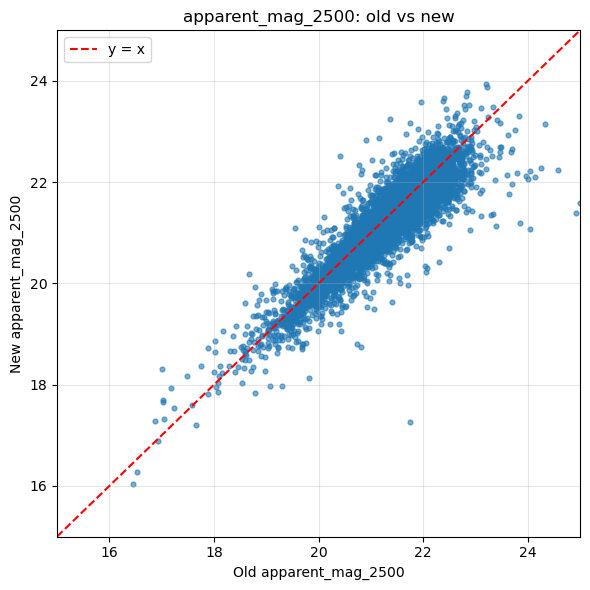

In [39]:
import matplotlib.pyplot as plt

# Keep only needed columns and align rows by object_id
old_2500 = df_old[["object_id", "apparent_mag_2500"]].rename(columns={"apparent_mag_2500": "old_2500"})
new_2500 = df_new[["object_id", "apparent_mag_2500"]].rename(columns={"apparent_mag_2500": "new_2500"})

cmp = old_2500.merge(new_2500, on="object_id", how="inner").dropna(subset=["old_2500", "new_2500"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(cmp["old_2500"], cmp["new_2500"], s=12, alpha=0.6)

# y = x reference line within requested limits
ax.plot([15, 25], [15, 25], "r--", linewidth=1.5, label="y = x")

ax.set_xlim(15, 25)
ax.set_ylim(15, 25)
ax.set_xlabel("Old apparent_mag_2500")
ax.set_ylabel("New apparent_mag_2500")
ax.set_title("apparent_mag_2500: old vs new")

ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


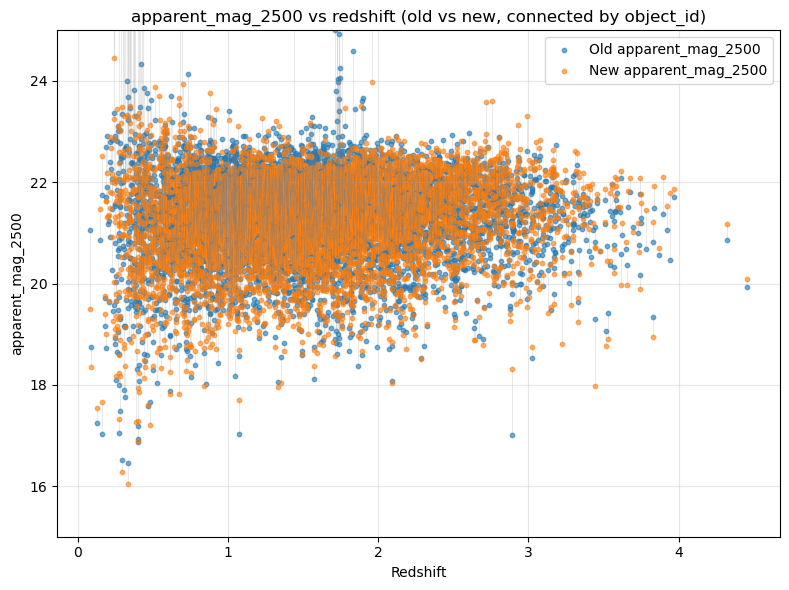

In [40]:
# Merge old/new apparent_mag_2500 and keep one redshift column
cmp_z = (
    df_old[["object_id", "apparent_mag_2500", "z"]]
    .rename(columns={"apparent_mag_2500": "old_2500", "z": "z_old"})
    .merge(
        df_new[["object_id", "apparent_mag_2500", "redshift"]].rename(
            columns={"apparent_mag_2500": "new_2500"}
        ),
        on="object_id",
        how="inner",
    )
)

cmp_z["z_plot"] = cmp_z["redshift"].fillna(cmp_z["z_old"])

# Remove NaNs and obvious sentinel values (e.g., -1e9)
cmp_z = cmp_z.dropna(subset=["z_plot", "old_2500", "new_2500"])
cmp_z = cmp_z[(cmp_z["old_2500"] > -100) & (cmp_z["new_2500"] > -100)]

fig, ax = plt.subplots(figsize=(8, 6))

# Connect old -> new for each object_id at the same redshift
ax.vlines(
    cmp_z["z_plot"],
    cmp_z["old_2500"],
    cmp_z["new_2500"],
    color="gray",
    alpha=0.2,
    linewidth=0.6,
)

# Old and new points
ax.scatter(cmp_z["z_plot"], cmp_z["old_2500"], s=10, alpha=0.6, label="Old apparent_mag_2500")
ax.scatter(cmp_z["z_plot"], cmp_z["new_2500"], s=10, alpha=0.6, label="New apparent_mag_2500")

ax.set_xlabel("Redshift")
ax.set_ylabel("apparent_mag_2500")
ax.set_title("apparent_mag_2500 vs redshift (old vs new, connected by object_id)")
ax.invert_yaxis()  # magnitudes: smaller = brighter
ax.set_ylim(15, 25)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

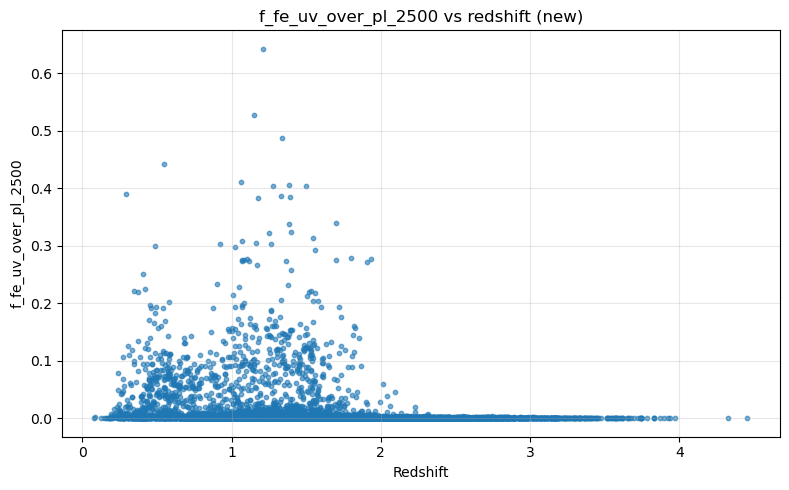

In [41]:
# Plot host fraction at 2500A vs redshift for the new catalog
ycol = "f_fe_uv_over_pl_2500"

plot_df = df_new[["redshift", ycol]].dropna().copy()
#plot_df = plot_df[(plot_df[ycol] >= 0) & (plot_df[ycol] <= 1)]  # remove sentinel/unphysical values

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df["redshift"], plot_df[ycol], s=10, alpha=0.6)

ax.set_xlabel("Redshift")
ax.set_ylabel(ycol)
ax.set_title(f"{ycol} vs redshift (new)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [42]:
len(df_new)

7239

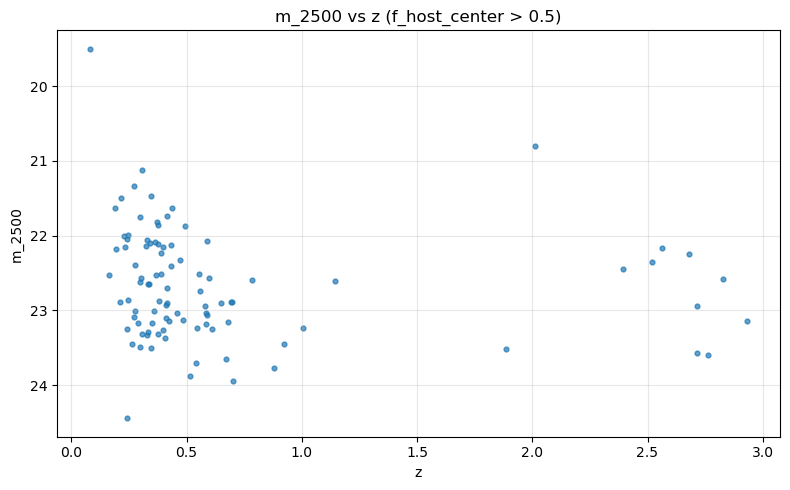

In [50]:
plot_df = df_new[["z", "apparent_mag_2500", "f_host_center"]].dropna().copy()
plot_df = plot_df[(plot_df["f_host_center"] > 0.5)]#& (plot_df["apparent_mag_2500"] > -100)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df["z"], plot_df["apparent_mag_2500"], s=12, alpha=0.7)

ax.set_xlabel("z")
ax.set_ylabel("m_2500")
ax.set_title("m_2500 vs z (f_host_center > 0.5)")
ax.invert_yaxis()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

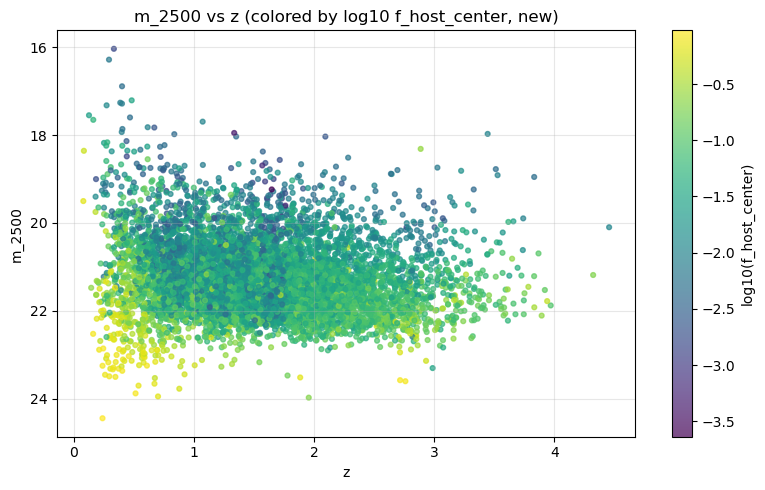

In [45]:
import numpy as np

tmp = df_new[["z", "apparent_mag_2500", "f_host_center"]].dropna().copy()
#tmp = tmp[(tmp["apparent_mag_2500"] > -100) & (tmp["f_host_center"] > 0)]
tmp["log_f_host_new"] = np.log10(tmp["f_host_center"])

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    tmp["z"],
    tmp["apparent_mag_2500"],
    c=tmp["log_f_host_new"],
    s=12,
    alpha=0.7,
    cmap="viridis",
)

ax.set_xlabel("z")
ax.set_ylabel("m_2500")
ax.set_title("m_2500 vs z (colored by log10 f_host_center, new)")
ax.invert_yaxis()
ax.grid(alpha=0.3)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("log10(f_host_center)")

fig.tight_layout()
plt.show()

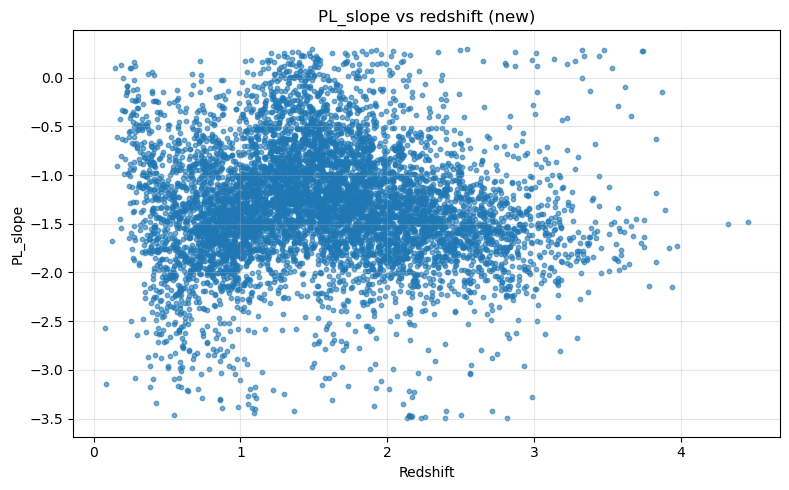

In [46]:
plot_df = df_new[["redshift", "PL_slope"]].dropna().copy()
plot_df = plot_df[(plot_df["PL_slope"] > -100) & (plot_df["PL_slope"] < 100)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df["redshift"], plot_df["PL_slope"], s=10, alpha=0.6)

ax.set_xlabel("Redshift")
ax.set_ylabel("PL_slope")
ax.set_title("PL_slope vs redshift (new)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

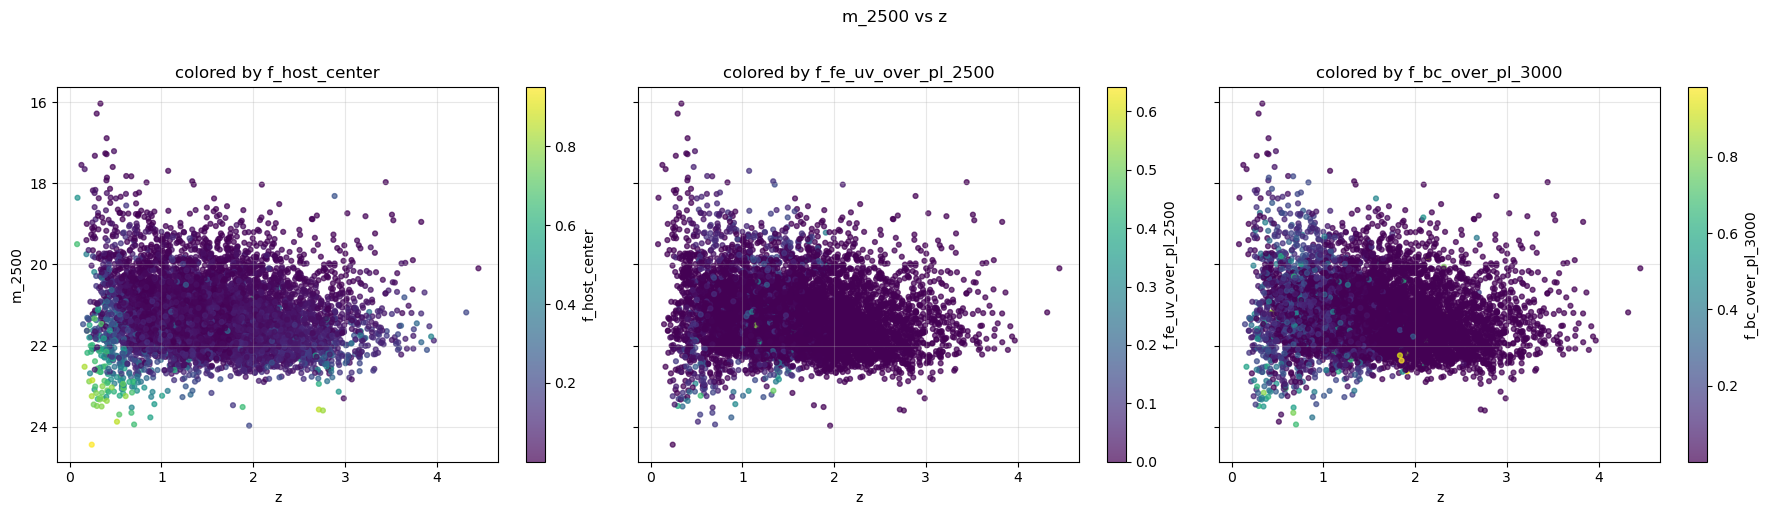

In [47]:
color_cols = ["f_host_center", "f_fe_uv_over_pl_2500", "f_bc_over_pl_3000"]

base = df_new[["z", "apparent_mag_2500"] + color_cols].copy()
base = base.dropna(subset=["z", "apparent_mag_2500"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, ccol in zip(axes, color_cols):
    d = base.dropna(subset=[ccol]).copy()
    d = d[(d[ccol] >= 0) & (d[ccol] <= 1)]  # remove sentinel/unphysical values

    sc = ax.scatter(
        d["z"],
        d["apparent_mag_2500"],
        c=d[ccol],
        s=12,
        alpha=0.7,
        cmap="viridis",
    )

    ax.set_title(f"colored by {ccol}")
    ax.set_xlabel("z")
    ax.grid(alpha=0.3)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(ccol)

axes[0].set_ylabel("m_2500")
axes[0].invert_yaxis()

fig.suptitle("m_2500 vs z", y=1.02)
fig.tight_layout()
plt.show()